In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../task-2/Bakery.csv")

df.head()

,TransactionNo,Items,DateTime,Daypart,DayType
0,1,Bread,2016-10-30 09:58:11,Morning,Weekend
1,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
2,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
3,3,Hot chocolate,2016-10-30 10:07:57,Morning,Weekend
4,3,Jam,2016-10-30 10:07:57,Morning,Weekend


In [4]:
print("Shape of dataset:", df.shape)

df.info()


Shape of dataset: (20507, 5)
<class 'pandas.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionNo  20507 non-null  int64
 1   Items          20507 non-null  str  
 2   DateTime       20507 non-null  str  
 3   Daypart        20507 non-null  str  
 4   DayType        20507 non-null  str  
dtypes: int64(1), str(4)
memory usage: 801.2 KB


In [5]:
df.isnull().sum()


TransactionNo    0
Items            0
DateTime         0
Daypart          0
DayType          0
dtype: int64

In [6]:
df.describe(include='all')

,TransactionNo,Items,DateTime,Daypart,DayType
count,20507.000000,20507,20507,20507,20507
unique,NaN,94,9465,4,2
top,NaN,Coffee,2017-09-02 13:44:56,Afternoon,Weekday
freq,NaN,5471,11,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN


In [7]:
print("Total unique items:", df['Items'].nunique())

Total unique items: 94


In [8]:
top_items = df['Items'].value_counts().head(10)

print(top_items)

Items
Coffee           5471
Bread            3325
Tea              1435
Cake             1025
Pastry            856
Sandwich          771
Medialuna         616
Hot chocolate     590
Cookies           540
Brownie           379
Name: count, dtype: int64


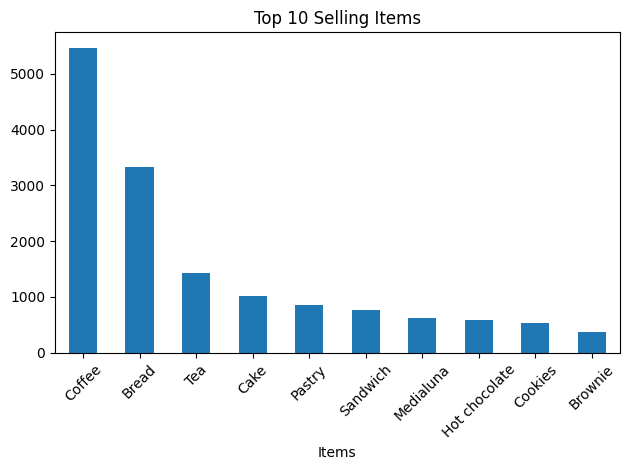

In [13]:
import os
import matplotlib.pyplot as plt

os.makedirs("visuals", exist_ok=True)

top_items.plot(kind='bar')

plt.title("Top 10 Selling Items")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("visuals/top_items.png")
plt.show()

In [11]:
daypart_sales = df['Daypart'].value_counts()

print(daypart_sales)


Daypart
Afternoon    11569
Morning       8404
Evening        520
Night           14
Name: count, dtype: int64


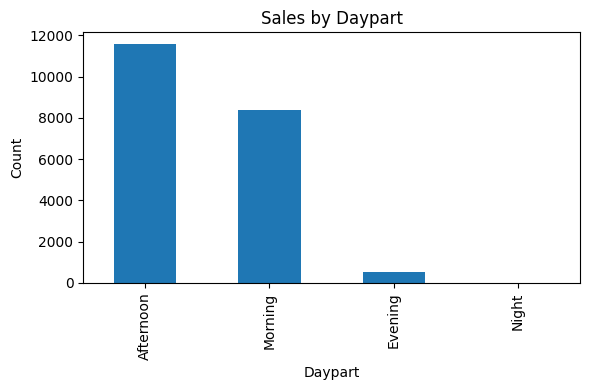

In [14]:
plt.figure(figsize=(6,4))
daypart_sales.plot(kind='bar')

plt.title("Sales by Daypart")
plt.xlabel("Daypart")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("visuals/daypart_sales.png")
plt.show()

In [15]:
daytype_sales = df['DayType'].value_counts()

print(daytype_sales)

DayType
Weekday    12807
Weekend     7700
Name: count, dtype: int64


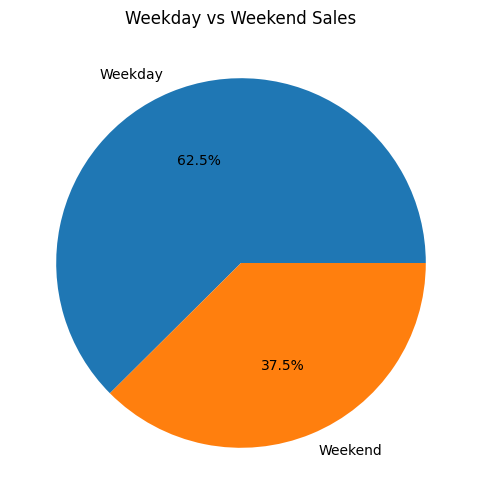

In [17]:
plt.figure(figsize=(6,6))
daytype_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Weekday vs Weekend Sales")

plt.ylabel("")

plt.savefig("visuals/daytype_sales.png")
plt.show()

In [18]:
morning_sales = df[df['Daypart'] == "Morning"]

morning_top = morning_sales['Items'].value_counts().head(10)

print(morning_top)

Items
Coffee           2561
Bread            1610
Pastry            604
Tea               456
Medialuna         402
Cake              264
Hot chocolate     232
Farm House        210
Cookies           206
Toast             204
Name: count, dtype: int64


In [19]:
weekend_sales = df[df['DayType'] == "Weekend"]

weekend_top = weekend_sales['Items'].value_counts().head(10)

print(weekend_top)

Items
Coffee           1928
Bread            1233
Tea               459
Cake              413
Pastry            290
Medialuna         277
Sandwich          259
Hot chocolate     250
Scone             203
Brownie           172
Name: count, dtype: int64


In [20]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['Hour'] = df['DateTime'].dt.hour

In [21]:
hour_sales = df['Hour'].value_counts().sort_index()

print(hour_sales)

Hour
1        1
7       24
8      645
9     1966
10    2666
11    3102
12    2854
13    2617
14    2640
15    2115
16    1343
17     368
18      82
19      48
20      22
21       3
22       8
23       3
Name: count, dtype: int64


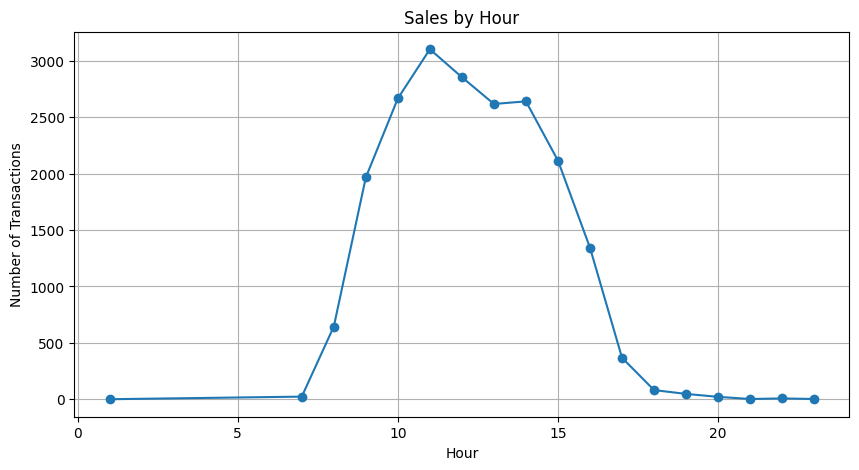

In [23]:
plt.figure(figsize=(10,5))
hour_sales.plot(kind='line', marker='o')

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.grid()

plt.savefig("visuals/hour_sales.png")
plt.show()

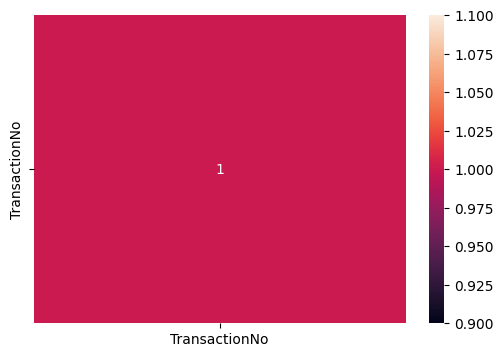

In [24]:
# Only works if numeric columns exist
numeric_df = df.select_dtypes(include=['int64', 'float64'])

if not numeric_df.empty:
    plt.figure(figsize=(6,4))
    sns.heatmap(numeric_df.corr(), annot=True)
    plt.show()